---

##  Regression Evaluation Metrics

Once we have trained our model, we need to evaluate how well it performs on unseen data.




### 1. MAE (Mean Absolute Error)
The average of the absolute differences between actual and predicted values.
$$ MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$
*   **Pros:** Easy to interpret (same units as $y$). Robust to outliers.
*   **Cons:** Not differentiable at zero (harder to use in gradient descent without modifications).

### 2. MSE (Mean Squared Error)
The average of the squared differences.
$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$
*   **Pros:** Differentiable everywhere. Penalizes large errors heavily.
*   **Cons:** Highly sensitive to outliers. Units are squared (hard to interpret).

### 3. RMSE (Root Mean Squared Error)
The square root of MSE.
$$ RMSE = \sqrt{MSE} $$
*   **Pros:** Same units as the target variable $y$ (highly interpretable). Penalizes large errors like MSE.
*   **Cons:** Still sensitive to outliers.

### 4. R² Score (Coefficient of Determination)
Represents the proportion of variance in the dependent variable that is predictable from the independent variables.

$$R^2 = 1 - \frac{\text{Sum of Squared Residuals } (SS_{res})}{\text{Total Sum of Squares } (SS_{tot})}$$



*   **Range:** $-\infty$ to $1$. (1 is perfect, 0 is as good as a horizontal line/mean predictor, negative means the model is worse than the mean).


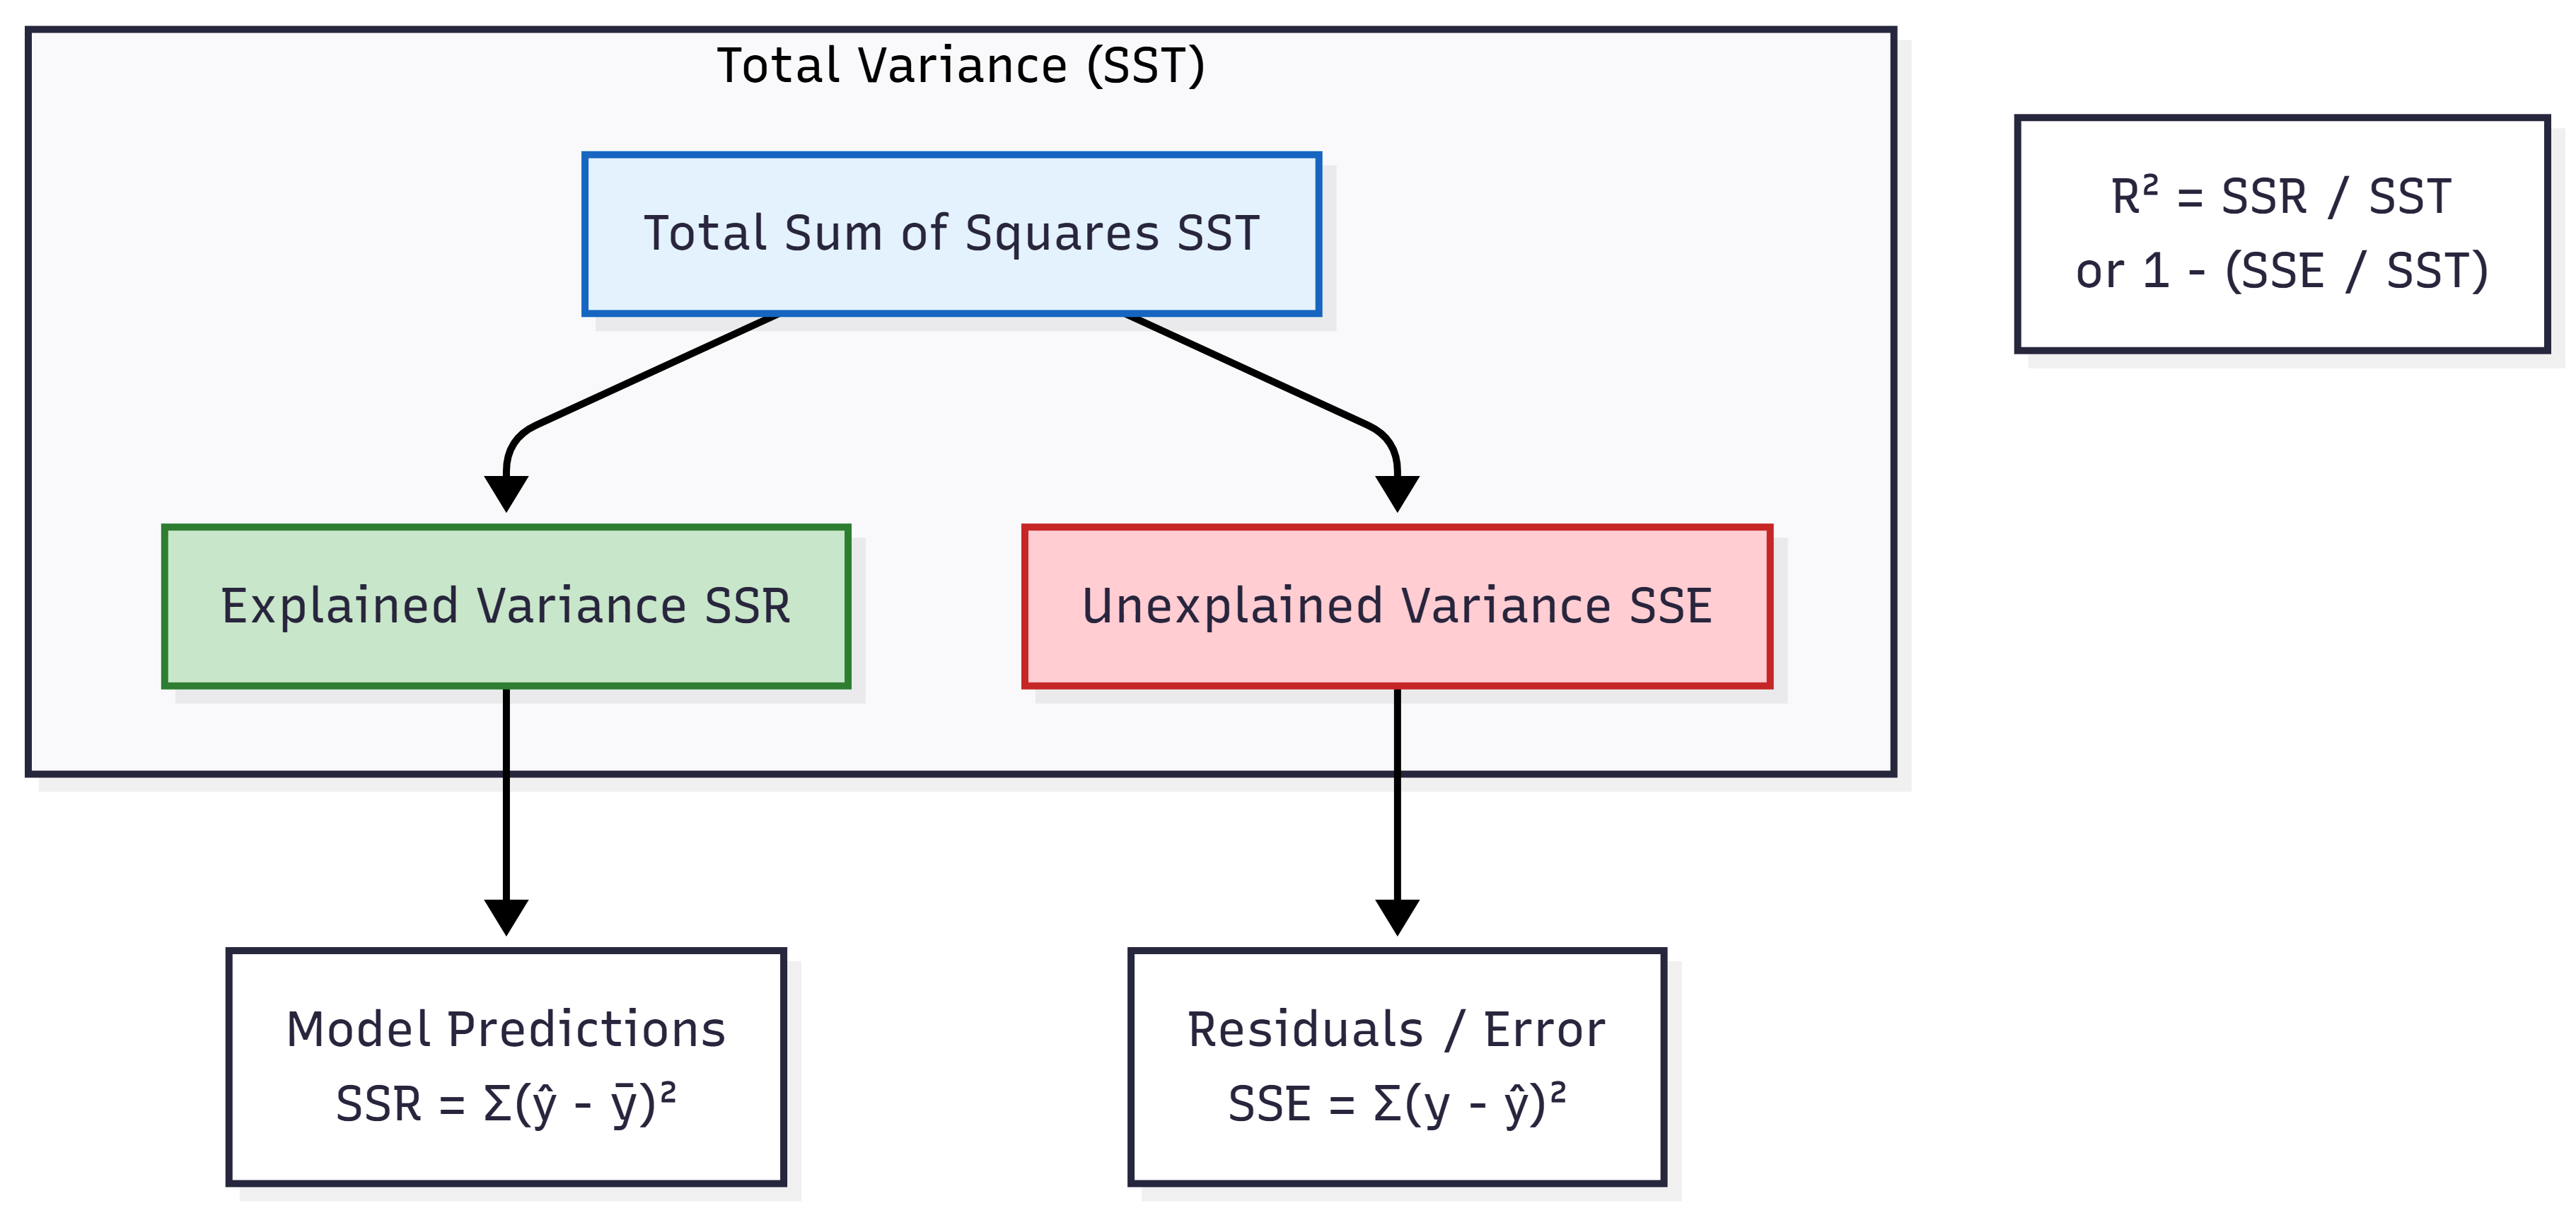


### 5. Adjusted R² Score
A modified version of R² that adjusts for the number of predictors in the model. The standard $R^2$ score artificially increases when you add more features to a model, even if they are useless. Adjusted $R^2$ corrects this by penalising the addition of non-informative variables.

$$R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - p - 1} \right]$$

*(where $n$ is the number of data points (sample size) and $p$ is the number of independent variables (predictors)).*

*   **Pros:** Penalizes the addition of useless features. Only increases if the new feature improves the model more than would be expected by chance.

### Metrics Summary Table

| Metric | Formula Concept | Best Value | Sensitive to Outliers | Interpretability |
|--------|-----------------|------------|-----------------------|------------------|
| **MAE** | Avg Absolute Error | 0 | ❌ No | ⭐⭐⭐ High (Same units) |
| **MSE** | Avg Squared Error | 0 | ✅ Yes | ⭐ Low (Squared units) |
| **RMSE** | $\sqrt{MSE}$ | 0 | ✅ Yes | ⭐⭐⭐ High (Same units) |
| **R²** | Variance Explained | 1 | ⚠️ Moderate | ⭐⭐⭐ High (Percentage) |
| **Adj R²** | Penalized R² | 1 | ⚠️ Moderate | ⭐⭐⭐ High (Percentage) |

---



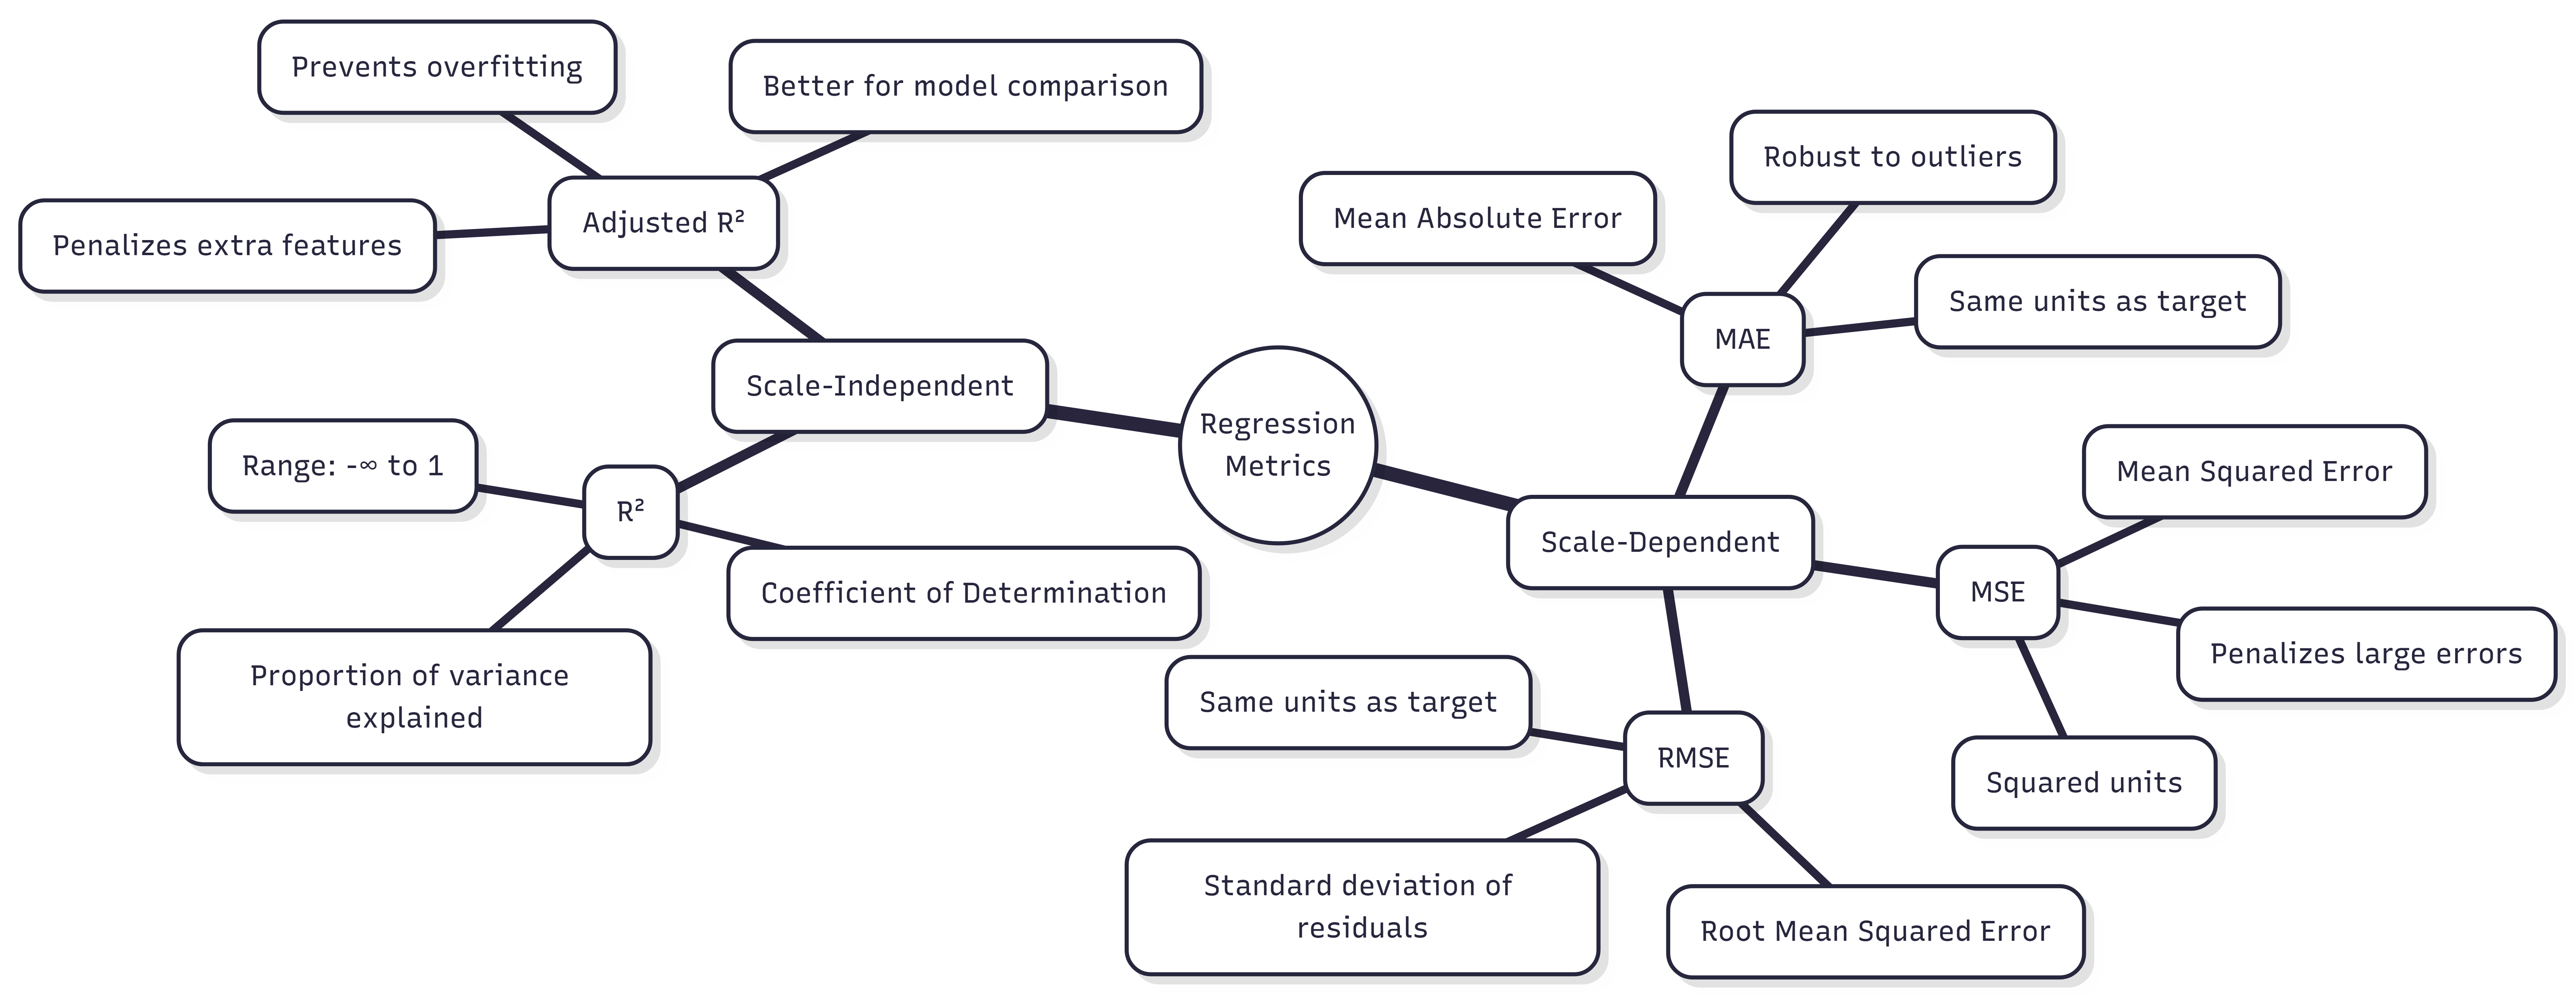

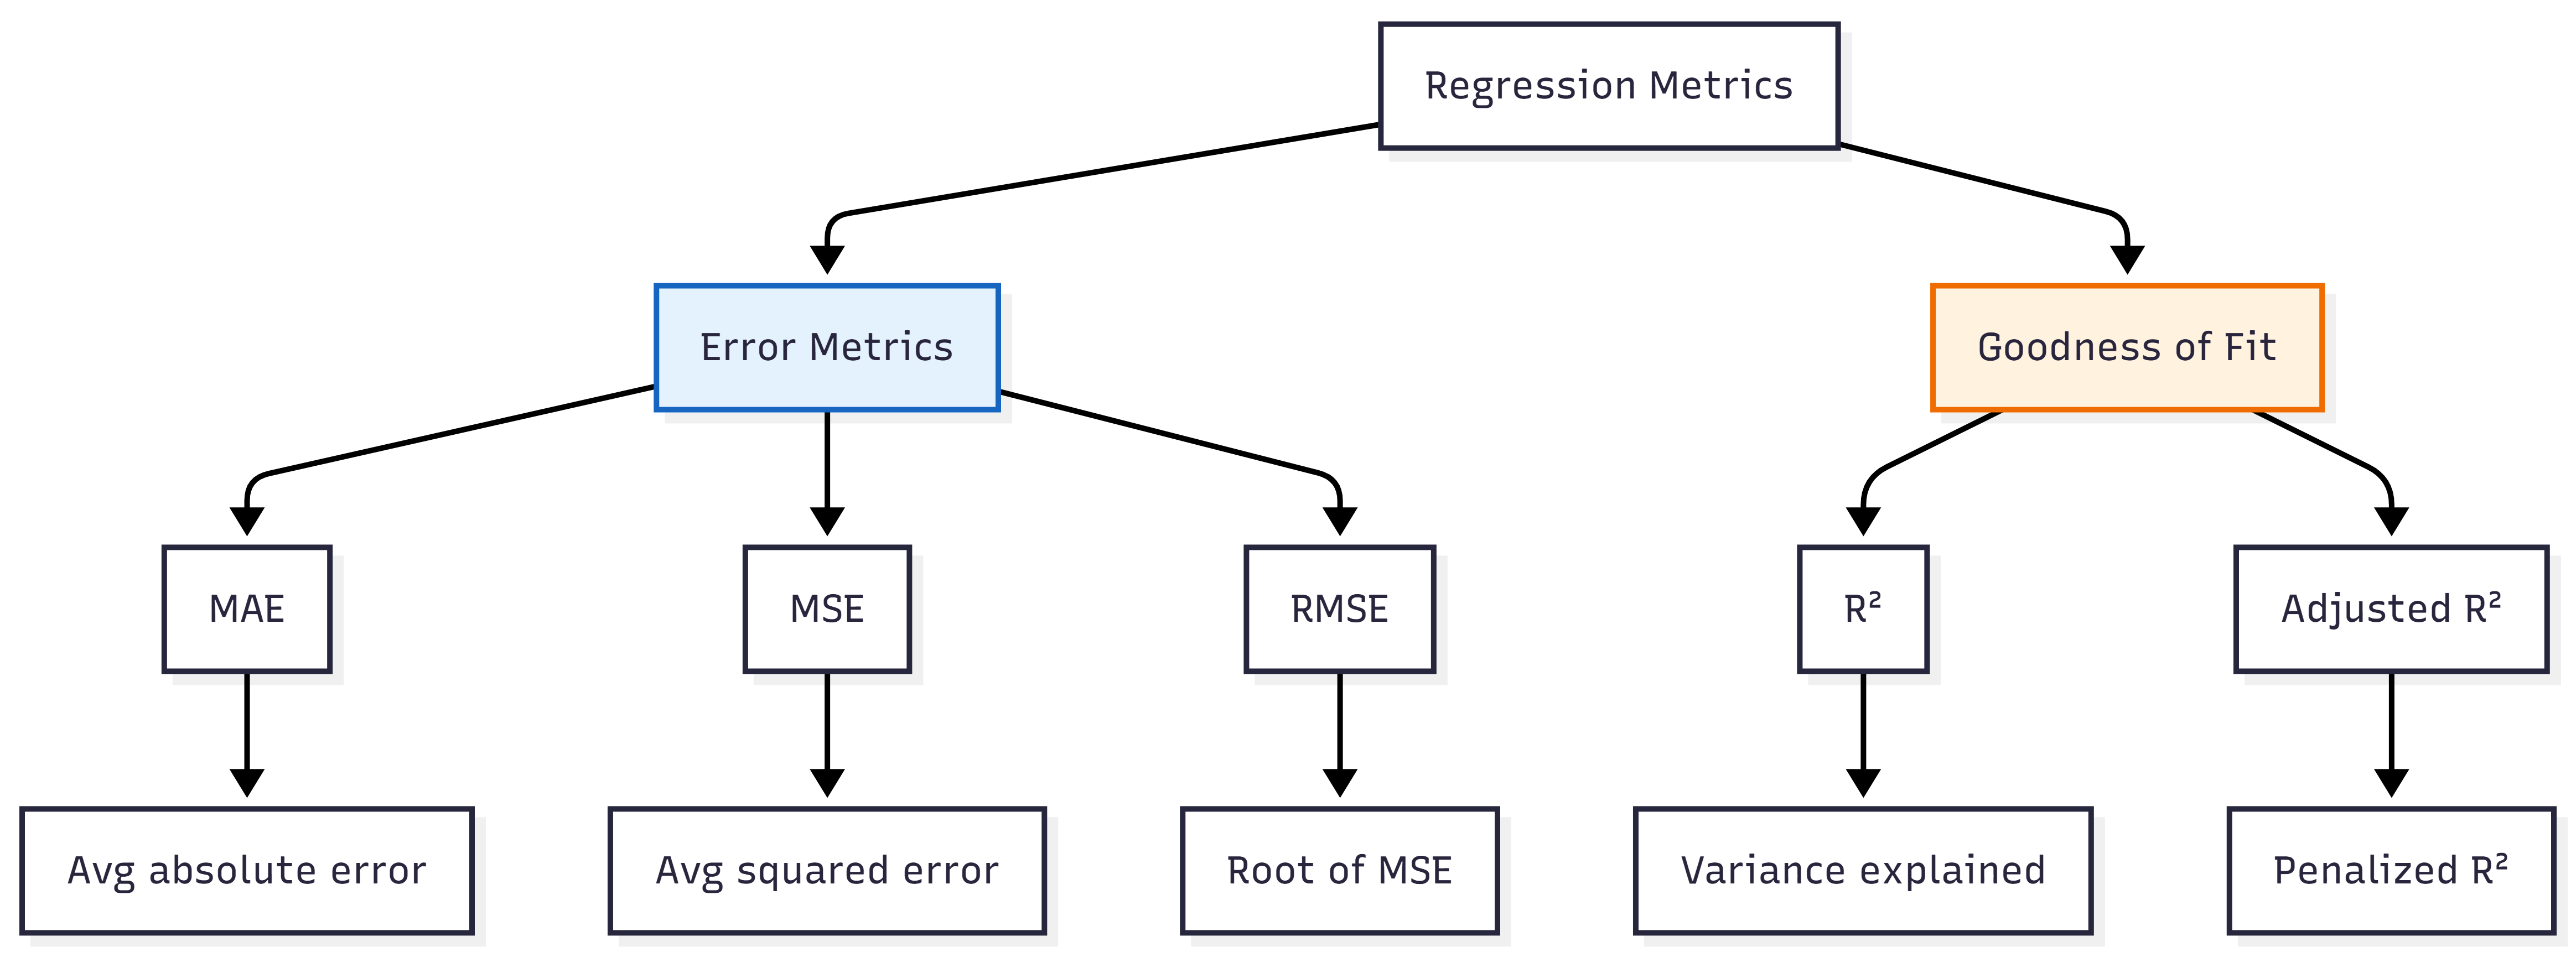

## Comprehensive Code Implementations

### Example 1: Simple Linear Regression (Scikit-Learn)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# 1. Create Dummy Data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise

# 2. Train Model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"Intercept (b): {model.intercept_[0]:.2f}")
print(f"Coefficient (m): {model.coef_[0][0]:.2f}")


Intercept (b): 4.22
Coefficient (m): 2.77


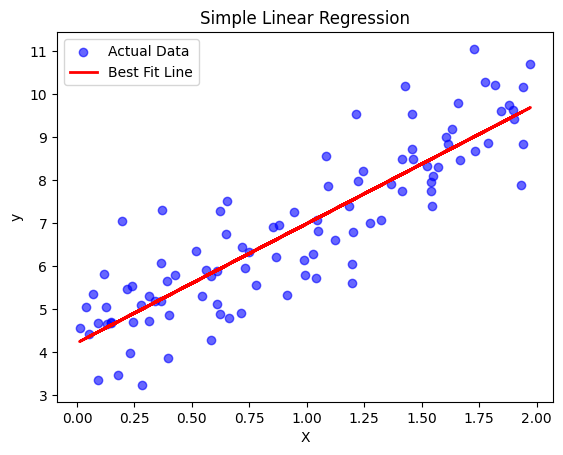

In [3]:
# 3. Visualize
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Best Fit Line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Simple Linear Regression')
plt.show()


### Example: Custom Gradient Descent Implementation (From Scratch)


In [5]:
class CustomGradientDescent:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iters = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1)) # Modified: Initialize weights as a 2D column vector
        self.bias = 0

        for i in range(self.iters):
            # 1. Forward Pass (Predictions)
            y_pred = np.dot(X, self.weights) + self.bias

            # 2. Compute Cost (MSE)
            cost = (1/n_samples) * np.sum((y - y_pred)**2)
            self.cost_history.append(cost)

            # 3. Compute Gradients
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            # 4. Update Parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Usage
gd_model = CustomGradientDescent(learning_rate=0.1, iterations=500)
gd_model.fit(X, y)
print(f"GD Weights: {gd_model.weights}, Bias: {gd_model.bias}")

GD Weights: [[2.77028186]], Bias: 4.2149053534036485


In [ ]:

### Example 3: Evaluating Regression Metrics


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

# Using California Housing Dataset
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data for Regularized models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train OLS Model
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)
y_pred_ols = ols_model.predict(X_test)

# Calculate Metrics
mae = mean_absolute_error(y_test, y_pred_ols)
mse = mean_squared_error(y_test, y_pred_ols)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ols)

# Adjusted R2
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("=== OLS Regression Metrics ===")
print(f"MAE:           {mae:.4f}")
print(f"MSE:           {mse:.4f}")
print(f"RMSE:          {rmse:.4f}")
print(f"R2 Score:      {r2:.4f}")
print(f"Adjusted R2:   {adj_r2:.4f}")



---

## 7. Assumptions of Linear Regression

To trust the results and p-values of a Linear Regression model, the data must satisfy the **LINE** assumptions:

1. **L - Linearity:** The relationship between the independent and dependent variables is linear.
2. **I - Independence:** The observations are independent of each other (no autocorrelation).
3. **N - Normality:** The residuals (errors) are normally distributed.
4. **E - Equal Variance (Homoscedasticity):** The variance of residual is relatively constant across all levels of the predicted value.
5. **No Multicollinearity:** (For MLR) Independent variables are not highly correlated with each other.

---

## 8. Interview Questions & Key Takeaways

### 🎯 Top Interview Questions

**Q1: What is the difference between R² and Adjusted R²?**
> **A:** R² measures the proportion of variance explained by the model, but it *always* increases (or stays the same) when you add more features, even if they are useless. Adjusted R² penalizes the addition of irrelevant features, making it a more reliable metric for Multiple Linear Regression.

**Q2: Why do we square the errors in MSE instead of taking the absolute value?**
> **A:** Squaring the errors serves three purposes:
> 1. It removes negative signs (preventing errors from canceling each other out).
> 2. It heavily penalizes large errors (outliers), forcing the model to focus on minimizing massive deviations.
> 3. It creates a smooth, continuous, and differentiable convex function, which is mathematically easier to optimize using Gradient Descent.

**Q3: When should we prefer SGD over OLS?**
> **A:** We should use Stochastic Gradient Descent (SGD) when dealing with massive datasets that cannot fit into memory, when we need online learning (updating the model as new streaming data arrives), or when the feature matrix is not invertible (multicollinearity).

**Q4: What happens if the Learning Rate is too high or too low?**
> **A:** If it's too high, the model will overshoot the minimum and diverge (loss increases). If it's too low, the model will take tiny steps, resulting in extremely slow convergence and the risk of getting stuck in local minima.

**Q5: How does Lasso Regression perform feature selection?**
> **A:** Lasso uses L1 regularization, which adds the absolute value of weights to the loss function. This penalty forces the coefficients of less important features to shrink exactly to zero, effectively removing them from the model.



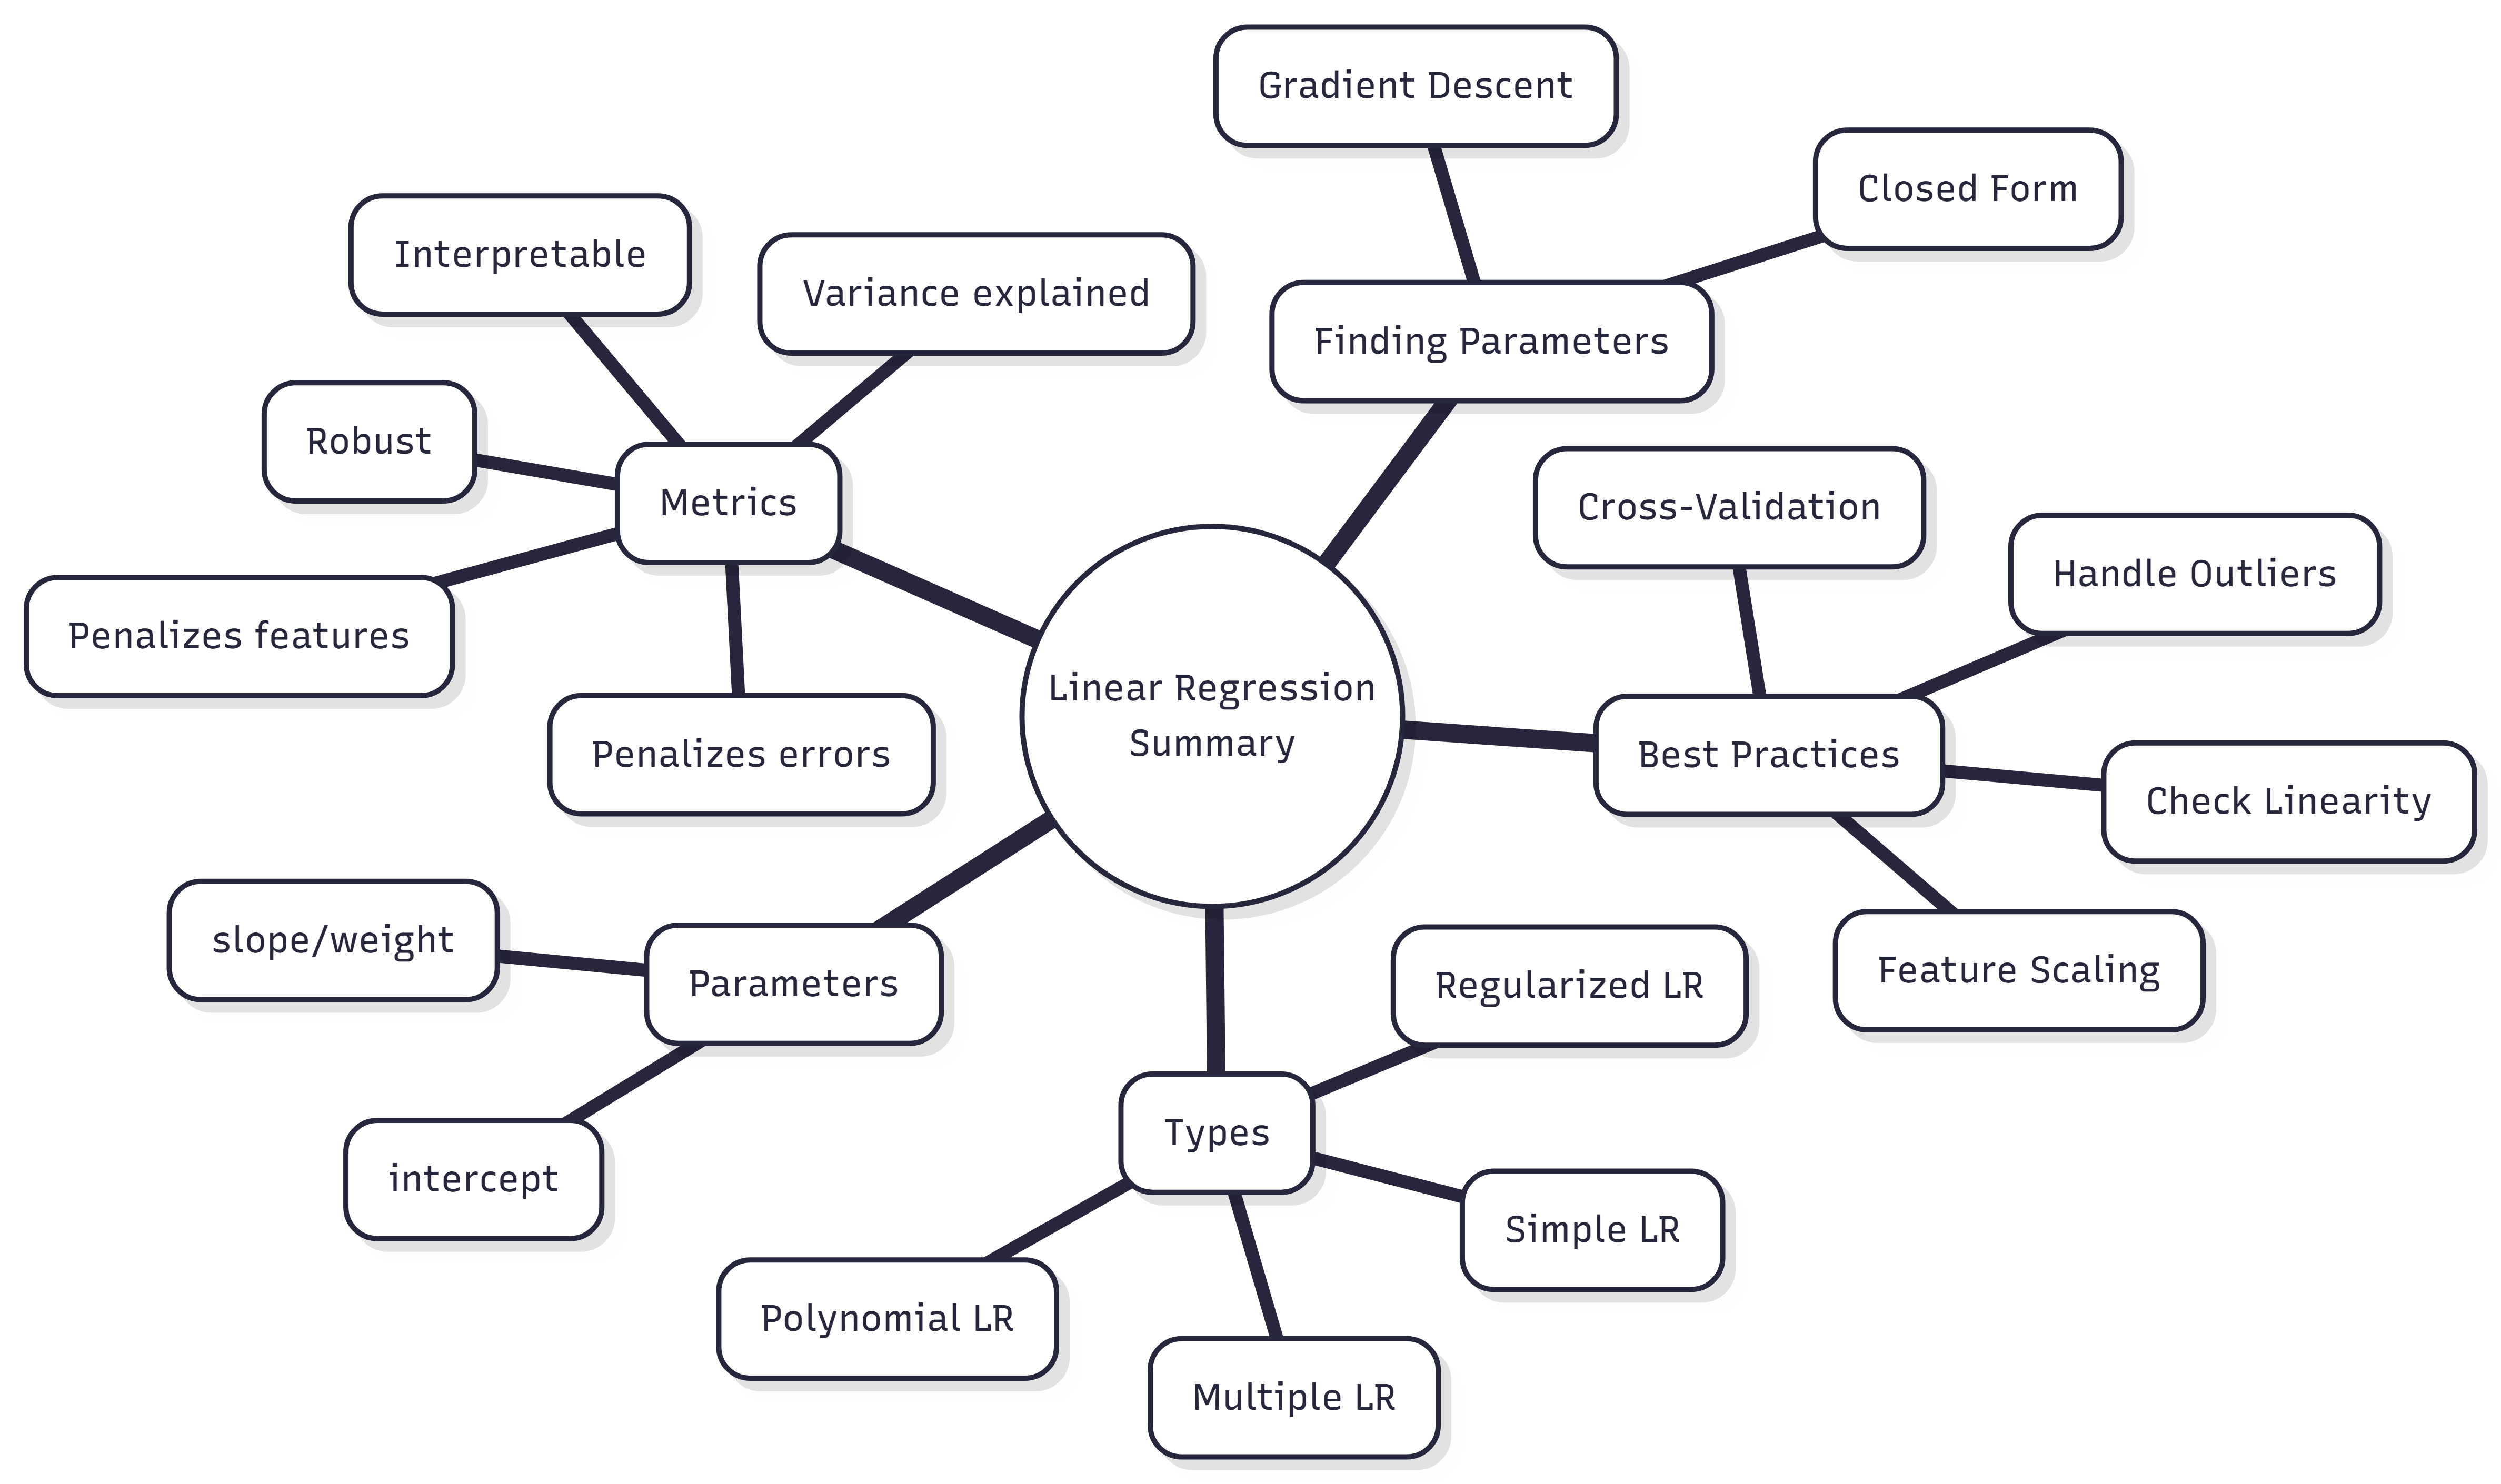